# EDA CREDIT RISK ANALYSIS 
### By Rajeev Kumar

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import random

In [2]:
df = pd.read_csv(r"C:\Data Analytics\Projects\END TO END\Credit_Risk_Analysis\Dataset\Clean_dataset\credit_risk_merged.csv")

In [3]:
r,c = df.shape

print(f'''Table Contains : 
ROWS : {r} 
Columns : {c} ''')

Table Contains : 
ROWS : 352500 
Columns : 41 


In [4]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', c)

In [5]:
df.head()

,Applicant_ID,Applicant_Name,Age,Gender,City,Region,Employment_Type,Education,Marital_Status,Annual_Income,Credit_Score,Dependents,Years_At_Job,Own_House,Credit_Score_Category,Age_Group,Income_Category,Loan_ID,Loan_Type,Loan_Amount,Interest_Rate,Loan_Tenure_Months,Loan_Purpose,Loan_Grade,Issue_Date,Debt_To_Income_%,Loan_Status,Issue_Year,Issue_Month,Issue_Quarter,DTI_Risk,Loan_Size,Repayment_ID,EMI_Month,Due_Date,Paid_Date,EMI_Amount,Amount_Paid,DPD_Days,Payment_Status,Default_Flag
0,APP00001,Kavita Mishra,42,Male,Faridabad,North,Salaried,Post Graduate,Single,695112,698,1,0,Yes,Good,41-50,Middle,LN025973,Education Loan,651000,15.73,60,Vehicle Purchase,D,2023-06-13,27.17,Active,2023,6,2,Moderate Risk,Large,REP0305155,1,2023-07-13,2023-07-13,15737.81,15737.81,0,On Time,0
1,APP00001,Kavita Mishra,42,Male,Faridabad,North,Salaried,Post Graduate,Single,695112,698,1,0,Yes,Good,41-50,Middle,LN025973,Education Loan,651000,15.73,60,Vehicle Purchase,D,2023-06-13,27.17,Active,2023,6,2,Moderate Risk,Large,REP0305156,2,2023-08-12,2023-08-13,15737.81,15737.81,1,Late,0
2,APP00001,Kavita Mishra,42,Male,Faridabad,North,Salaried,Post Graduate,Single,695112,698,1,0,Yes,Good,41-50,Middle,LN025973,Education Loan,651000,15.73,60,Vehicle Purchase,D,2023-06-13,27.17,Active,2023,6,2,Moderate Risk,Large,REP0305157,3,2023-09-11,2023-09-11,15737.81,15737.81,0,On Time,0
3,APP00001,Kavita Mishra,42,Male,Faridabad,North,Salaried,Post Graduate,Single,695112,698,1,0,Yes,Good,41-50,Middle,LN025973,Education Loan,651000,15.73,60,Vehicle Purchase,D,2023-06-13,27.17,Active,2023,6,2,Moderate Risk,Large,REP0305158,4,2023-10-11,2023-10-11,15737.81,15737.81,0,On Time,0
4,APP00001,Kavita Mishra,42,Male,Faridabad,North,Salaried,Post Graduate,Single,695112,698,1,0,Yes,Good,41-50,Middle,LN025973,Education Loan,651000,15.73,60,Vehicle Purchase,D,2023-06-13,27.17,Active,2023,6,2,Moderate Risk,Large,REP0305159,5,2023-11-10,2023-11-10,15737.81,15737.81,0,On Time,0


In [6]:
all_columns = df.columns.tolist()

In [7]:
print(f'''Table Contains : 
ROWS : {r} 
Columns : {c} ''')

print(f'''Table Details : 
{df.info()}''')

Table Contains : 
ROWS : 352500 
Columns : 41 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352500 entries, 0 to 352499
Data columns (total 41 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Applicant_ID           352500 non-null  object 
 1   Applicant_Name         352500 non-null  object 
 2   Age                    352500 non-null  int64  
 3   Gender                 352500 non-null  object 
 4   City                   352500 non-null  object 
 5   Region                 352500 non-null  object 
 6   Employment_Type        352500 non-null  object 
 7   Education              352500 non-null  object 
 8   Marital_Status         352500 non-null  object 
 9   Annual_Income          352500 non-null  int64  
 10  Credit_Score           352500 non-null  int64  
 11  Dependents             352500 non-null  int64  
 12  Years_At_Job           352500 non-null  int64  
 13  Own_House              352500 non-null  ob

# EDA 1 - Overall Default Rate

### What is the overall default rate in our loan portfolio?

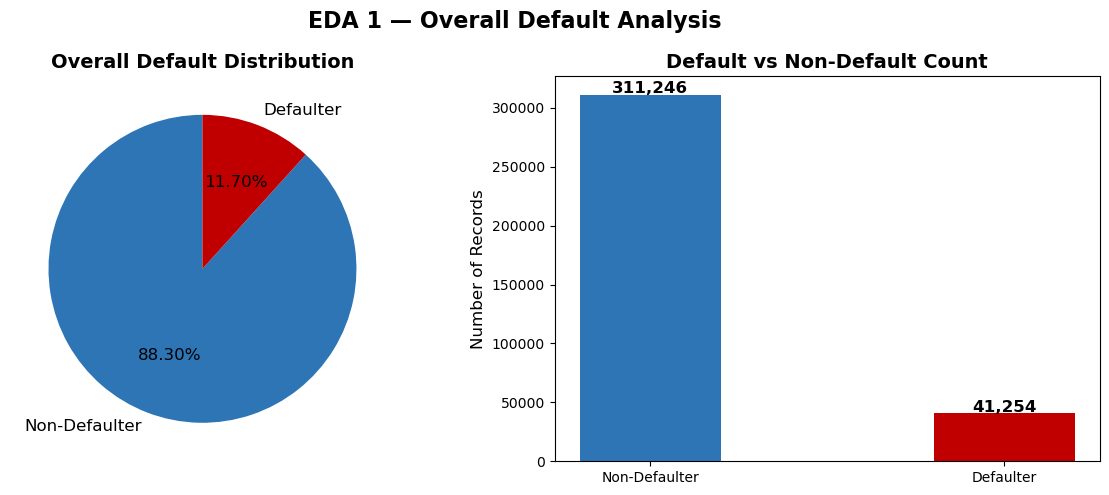

In [8]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

default_counts = df['Default_Flag'].value_counts() 
labels = ['Non-Defaulter','Defaulter']
colors = ['#2E75B6', '#C00000'] 

axes[0].pie(default_counts,labels=labels,colors=colors, 
           autopct='%1.2f%%', startangle = 90, 
           textprops = {'fontsize':12})

axes[0].set_title('Overall Default Distribution',
                 fontsize=14,fontweight = 'bold')

axes[1].bar(labels, default_counts, color=colors, width=0.4)
axes[1].set_title('Default vs Non-Default Count',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Records', fontsize=12)

for i, v in enumerate(default_counts):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center',
                 fontsize=12, fontweight='bold')

plt.suptitle('EDA 1 — Overall Default Analysis',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('eda1_overall_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
total     = len(df)
defaulted = df['Default_Flag'].sum()
rate      = round(defaulted / total * 100, 2)

In [10]:
print(f"Total Records    : {total:,}")
print(f"Total Defaulters : {defaulted:,}")
print(f"Default Rate     : {rate}%")
print(f"Industry Average : 5-8%")
print(f"Our Portfolio    : {rate}% — {'HIGH RISK' if rate > 8 else 'NORMAL'}")

Total Records    : 352,500
Total Defaulters : 41,254
Default Rate     : 11.7%
Industry Average : 5-8%
Our Portfolio    : 11.7% — HIGH RISK


## EDA 1 — Overall Default Analysis

**Key Finding:** Our loan portfolio has a default rate of 11.70%, which is significantly 
higher than the industry average of 5–8%.

- Total Records Analyzed: 3,52,500
- Total Defaulters: 41,254 (11.70%)
- Total Non-Defaulters: 3,11,246 (88.30%)
- Industry Benchmark: 5–8% default rate

**Business Insight:**  
Our portfolio default rate is almost double the industry average. This indicates 
a HIGH RISK portfolio where loan approval criteria may need to be tightened. 
Deeper analysis is needed to identify which customer segments and loan types 
are driving this elevated default rate.

# EDA 2 :- Loan Grade wise default rate kya hai?

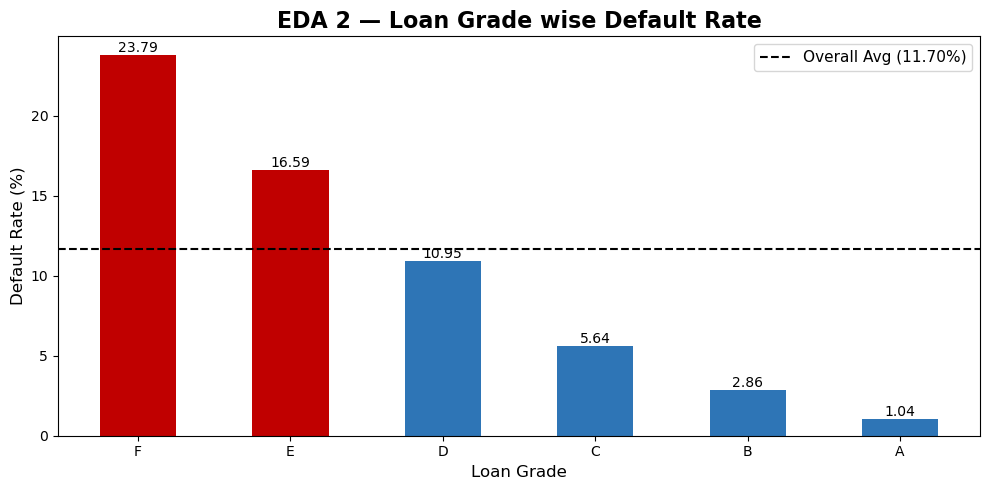

In [38]:
grade_default = df.groupby('Loan_Grade')['Default_Flag'].agg(['sum','count'])
grade_default['Default_Rate'] = round(grade_default['sum']/grade_default['count']*100,2) 
grade_default  = grade_default.sort_values('Default_Rate', ascending=False)

fig,ax  = plt.subplots(figsize=(10,5))
colors = ['#C00000' if r > 11.7 else '#2E75B6' for r in grade_default['Default_Rate']]

bars = ax.bar(grade_default.index, grade_default['Default_Rate'], color=colors, width=0.5)
ax.bar_label(bars)
ax.axhline(y=11.7, color='black', linestyle='--', linewidth=1.5, label='Overall Avg (11.70%)')
ax.set_title('EDA 2 — Loan Grade wise Default Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('Loan Grade', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=11)
plt.savefig('eda2_loangrade_default.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

## EDA 2 — Loan Grade wise Default Rate

**Key Finding:** Loan Grade is a strong predictor of default risk. 
Grade F borrowers default at 23.79% — almost 23x higher than Grade A (1.04%).

- Grade F: 23.79% default rate — CRITICAL RISK (2x the portfolio average)
- Grade E: 16.59% default rate — HIGH RISK (above average)
- Grade D: 10.95% default rate — MODERATE RISK (just below average)
- Grade C: 5.64% | Grade B: 2.86% | Grade A: 1.04% — SAFE ZONE

**Business Insight:**  
Grades E and F are driving the overall portfolio risk upward. 
Bank should tighten approval criteria for Grade E and F applicants, 
charge higher interest rates to compensate for risk, or limit 
exposure to these segments entirely.

# EDA 3 Credit Score Category wise default pattern?

In [16]:
df['Credit_Score_Category'].unique()

array(['Good', 'Very Good', 'Fair', 'Poor', 'Excellent'], dtype=object)

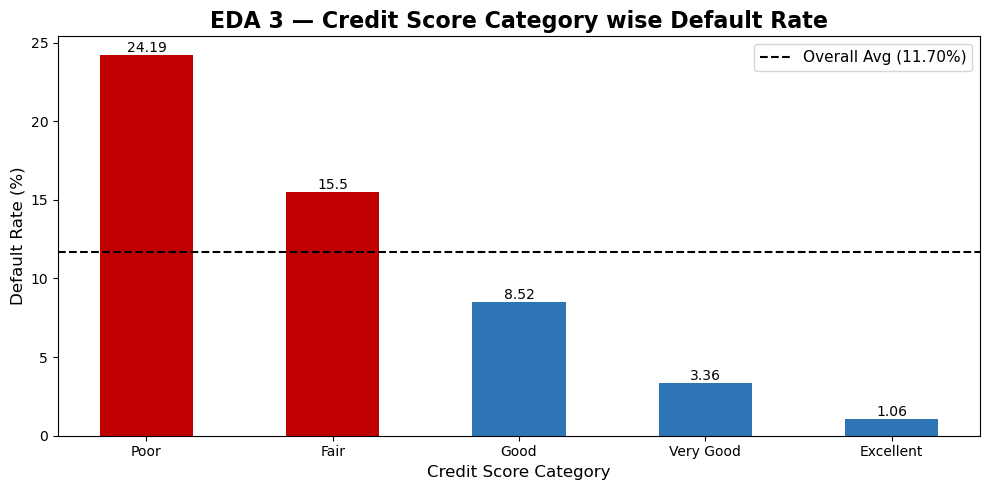

In [50]:
credit_default = df.groupby('Credit_Score_Category')['Default_Flag'].agg(['sum', 'count'])
credit_default['Default_Rate'] = round(credit_default['sum'] / credit_default['count'] * 100, 2)

category_order = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
credit_default = credit_default.reindex(category_order)

fig, ax = plt.subplots(figsize=(10,5))
colors = ['#C00000' if r > 11.7 else '#2E75B6' for r in credit_default['Default_Rate']] 
bars = ax.bar(credit_default.index, credit_default['Default_Rate'], color=colors, width=0.5)
ax.bar_label(bars)

ax.axhline(y=11.7, color='black', linestyle='--', linewidth=1.5, label='Overall Avg (11.70%)')
ax.set_title('EDA 3 — Credit Score Category wise Default Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('Credit Score Category', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda3_creditscore_default.png', dpi=150, bbox_inches='tight')
plt.show()

print(credit_default[['sum', 'count', 'Default_Rate']].rename(
    columns={'sum': 'Defaulters', 'count': 'Total Loans', 'Default_Rate': 'Default Rate %'}))

## EDA 3 — Credit Score Category wise Default Rate

**Key Finding:** Credit Score is a strong predictor of default risk.
Poor credit score borrowers default at 24.19% — 23x higher than Excellent (1.06%).

- Poor:     24.19% default rate — CRITICAL RISK (4,806 defaulters)
- Fair:     15.50% default rate — HIGH RISK (23,428 defaulters — highest count)
- Good:      8.52% default rate — MODERATE RISK (below average)
- Very Good: 3.36% default rate — LOW RISK
- Excellent: 1.06% default rate — VERY SAFE

**Business Insight:**
Poor and Fair credit score borrowers are the biggest contributors to 
portfolio default risk. Bank should tighten loan approval for Poor 
category and demand additional collateral from Fair category borrowers 
to reduce overall portfolio risk.

# EDA 4 Employment Type wise default rate?

In [21]:
df['Employment_Type'].unique()

array(['Salaried', 'Self-Employed', 'Government Employee',
       'Business Owner', 'Freelancer'], dtype=object)

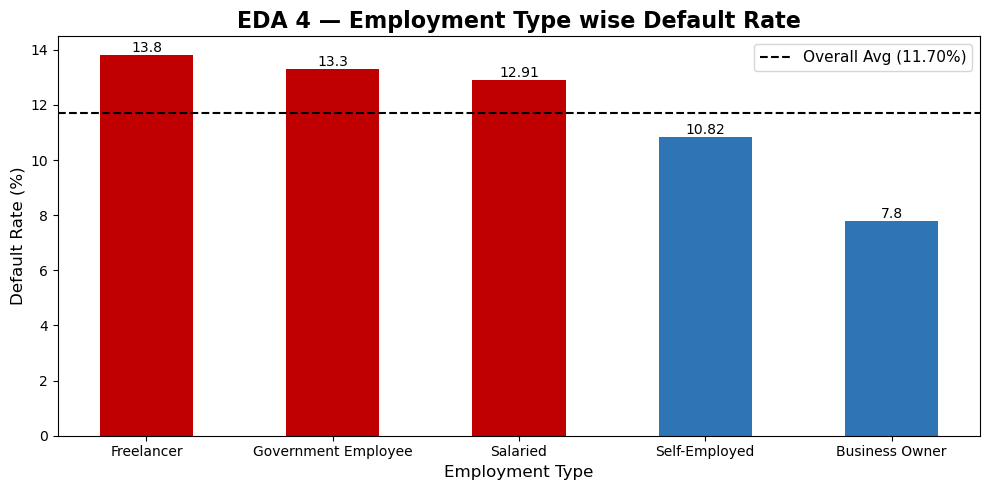

In [51]:
emp_default = df.groupby('Employment_Type').agg(
    Default_Rate=('Default_Flag', lambda x: round(x.mean() * 100, 2)),
    Defaulters=('Default_Flag', 'sum'),
    Total_Loans=('Default_Flag', 'count')
).sort_values('Default_Rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#C00000' if r > 11.7 else '#2E75B6' for r in emp_default['Default_Rate']]
bars = ax.bar(emp_default.index, emp_default['Default_Rate'], color=colors, width=0.5)
ax.bar_label(bars)

ax.axhline(y=11.7, color='black', linestyle='--', linewidth=1.5, label='Overall Avg (11.70%)')
ax.set_title('EDA 4 — Employment Type wise Default Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('Employment Type', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda4_employment_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
emp_default

,Default_Rate,Defaulters,Total_Loans
Employment_Type,,,
Freelancer,13.80,9754,70674
Government Employee,13.30,9186,69042
Salaried,12.91,9128,70716
Self-Employed,10.82,7531,69594
Business Owner,7.80,5655,72474


## EDA 4 — Employment Type wise Default Rate

**Key Finding:** Freelancers default the most (13.80%) and 
Business Owners default the least (7.80%).

- Freelancer:          13.80% — highest default — income is not fixed every month
- Government Employee: 13.30% — surprising — stable job but still defaulting a lot
- Salaried:            12.91% — above average — probably taking too many loans
- Self-Employed:       10.82% — below average — managing money better
- Business Owner:       7.80% — safest group — only 5,655 defaulters

**Business Insight:**
Employment Type alone does not tell the full story — the difference 
between highest and lowest is only 6%. But Freelancers should be 
checked more carefully before giving loans because their income 
is not stable. Government Employees defaulting at 13.30% is unexpected 
— they may be borrowing more than they can repay.

# EDA 5 Income Category wise default rate

In [26]:
df['Income_Category'].unique()

array(['Middle', 'Upper Middle', 'Lower Middle', 'High', 'Low'],
      dtype=object)

In [27]:
default_by_income = ((df.groupby('Income_Category')['Default_Flag'].mean()*100).round(2)).sort_values(ascending=False)

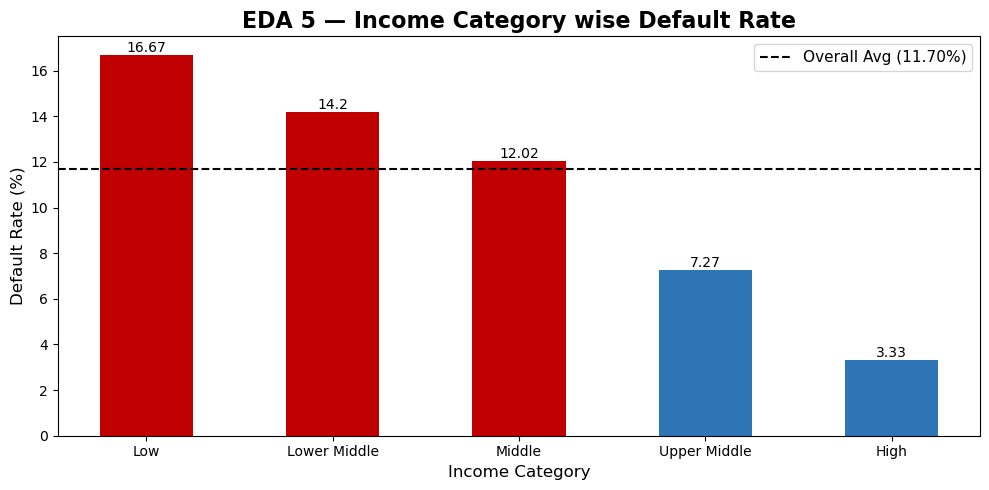

In [59]:
income_default = df.groupby('Income_Category').agg(
    Default_Rate = ('Default_Flag', lambda x : round(x.mean()*100,2)), 
    Defaulters = ('Default_Flag', 'sum'), 
    Total_Loans = ('Default_Flag','count')
)
category_order = ['Low', 'Lower Middle', 'Middle', 'Upper Middle', 'High']
income_default = income_default.reindex(category_order)
income_default

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#C00000' if r > 11.7 else '#2E75B6' for r in income_default['Default_Rate']]
bars = ax.bar(income_default.index, income_default['Default_Rate'], color=colors, width=0.5)

ax.bar_label(bars)

ax.axhline(y=11.7, color='black', linestyle='--', linewidth=1.5, label='Overall Avg (11.70%)')
ax.set_title('EDA 5 — Income Category wise Default Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('Income Category', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda5_income_default.png', dpi=150, bbox_inches='tight')
plt.show()



In [60]:
print(income_default)


                 Default_Rate  Defaulters  Total_Loans
Income_Category                                       
Low                     16.67        2914        17478
Lower Middle            14.20       14525       102306
Middle                  12.02       17821       148260
Upper Middle             7.27        5869        80700
High                     3.33         125         3756


## EDA 5 — Income Category wise Default Rate

**Key Finding:** Simple pattern — people who earn less, default more.
Low income group defaults at 16.67% and High income group at only 3.33%.

- Low:          16.67% — defaults the most — not enough money to pay EMI
- Lower Middle: 14.20% — still very risky — 14,525 people defaulted
- Middle:       12.02% — just above average — has the most loans (1,48,260)
- Upper Middle:  7.27% — doing well — earns enough to repay
- High:          3.33% — safest group — only 125 defaulters

**Business Insight:**
The pattern is very clear — as income goes up, defaults go down.
The Middle income group has the most loans in the whole portfolio — 
1,48,260 loans — and they are defaulting above average. 
This means bank is losing the most money from this group.
Bank

# EDA 6 — Loan Type wise Default Rate

In [62]:
df['Loan_Type'].unique()

array(['Education Loan', 'Auto Loan', 'Personal Loan', 'Gold Loan',
       'Business Loan', 'Home Loan'], dtype=object)

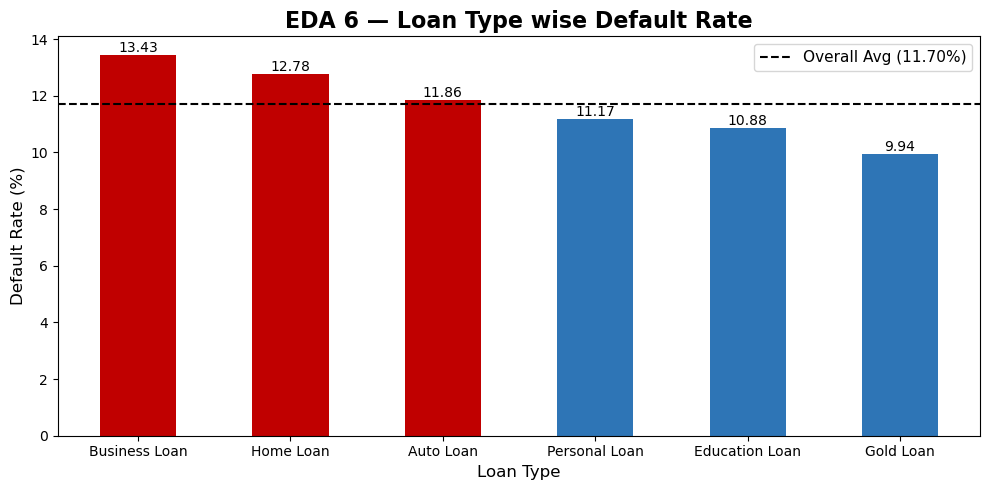

In [67]:
loan_default = df.groupby('Loan_Type').agg(
    Default_Rate=('Default_Flag', lambda x: round(x.mean() * 100, 2)),
    Defaulters=('Default_Flag', 'sum'),
    Total_Loans=('Default_Flag', 'count')
).sort_values('Default_Rate', ascending=False)


fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C00000' if r > 11.7 else '#2E75B6' for r in loan_default['Default_Rate']]
bars = ax.bar(loan_default.index, loan_default['Default_Rate'], color=colors, width=0.5)
ax.bar_label(bars)

ax.axhline(y=11.7, color='black', linestyle='--', linewidth=1.5, label='Overall Avg (11.70%)')
ax.set_title('EDA 6 — Loan Type wise Default Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('Loan Type', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda6_loantype_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
print(loan_default)


                Default_Rate  Defaulters  Total_Loans
Loan_Type                                            
Business Loan          13.43        7774        57876
Home Loan              12.78        7733        60492
Auto Loan              11.86        7123        60084
Personal Loan          11.17        6867        61488
Education Loan         10.88        6537        60060
Gold Loan               9.94        5220        52500


## EDA 6 — Loan Type wise Default Rate

**Key Finding:** Business Loan has the highest default rate (13.43%) 
and Gold Loan is the safest (9.94%).

- Business Loan:  13.43% — defaults the most — business income is not stable
- Home Loan:      12.78% — above average — loan amount is very large
- Auto Loan:      11.86% — just above average — car value drops over time
- Personal Loan:  11.17% — just below average — bank is already careful here
- Education Loan: 10.88% — below average — people repay after getting a job
- Gold Loan:       9.94% — safest — gold is kept as security with the bank

**Business Insight:**
All loan types have very similar default rates — the gap between 
highest and lowest is only 3.5%. This means loan type alone is 
not a strong signal for predicting defaults. 
Gold Loan is the safest because the bank holds gold as security — 
if someone does not pay, bank can sell the gold and recover money.
Business Loan is the riskiest — bank should check business cash 
flow carefully before approving these loans.

# EDA 7 — Age Group wise Default Rate

In [70]:
df['Age_Group'].unique()

array(['41-50', '51-65', '31-40', '21-30'], dtype=object)

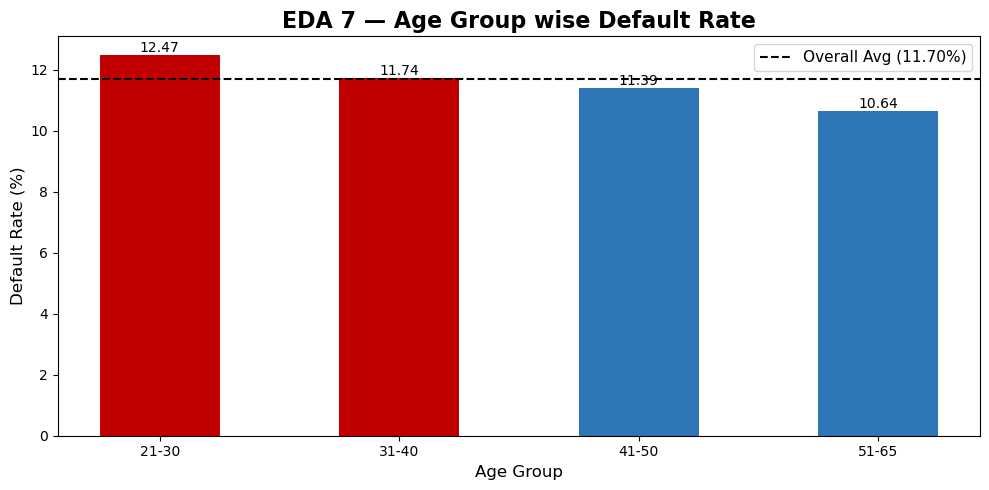

In [73]:
age_default = df.groupby('Age_Group').agg(
    Default_Rate=('Default_Flag', lambda x: round(x.mean() * 100, 2)),
    Defaulters=('Default_Flag', 'sum'),
    Total_Loans=('Default_Flag', 'count')
)

category_order = ['21-30', '31-40', '41-50', '51-65']
age_default = age_default.reindex(category_order)
age_default

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#C00000' if r > 11.7 else '#2E75B6' for r in age_default['Default_Rate']]
bars = ax.bar(age_default.index, age_default['Default_Rate'], color=colors, width=0.5)
ax.bar_label(bars)

ax.axhline(y=11.7, color='black', linestyle='--', linewidth=1.5, label='Overall Avg (11.70%)')
ax.set_title('EDA 7 — Age Group wise Default Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=11)


plt.tight_layout()
plt.savefig('eda7_agegroup_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [74]:
print(age_default)


           Default_Rate  Defaulters  Total_Loans
Age_Group                                       
21-30             12.47       10451        83802
31-40             11.74       15550       132438
41-50             11.39       11439       100404
51-65             10.64        3814        35856


## EDA 7 — Age Group wise Default Rate

**Key Finding:** Younger people default more than older people.
21-30 age group has the highest default rate (12.47%) and 
51-65 is the safest (10.64%).

- 21-30: 12.47% — defaults the most — low income, no savings, first time borrowers
- 31-40: 11.74% — above average — too many expenses at the same time
- 41-50: 11.39% — just below average — income is more stable now
- 51-65: 10.64% — safest group — settled financially, only 3,814 defaulters

**Business Insight:**
Age group is not a strong signal for predicting defaults — the gap 
between youngest and oldest is only 1.83%. All age groups are 
defaulting at similar rates. The 31-40 group has the most loans 
(1,32,438) and is still above average risk — bank should check 
their total debt before approving new loans.

# EDA 8 — DTI Risk wise Default Rate

In [76]:
df['DTI_Risk'].unique()

array(['Moderate Risk', 'High Risk', 'Very High Risk', 'Low Risk'],
      dtype=object)

In [77]:
dti_default = df.groupby('DTI_Risk').agg(
    Default_Rate=('Default_Flag', lambda x: round(x.mean() * 100, 2)),
    Defaulters=('Default_Flag', 'sum'),
    Total_Loans=('Default_Flag', 'count')
)

category_order = ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']
dti_default = dti_default.reindex(category_order)

dti_default

,Default_Rate,Defaulters,Total_Loans
DTI_Risk,,,
Low Risk,10.02,13348,133230
Moderate Risk,10.88,9982,91722
High Risk,11.81,6421,54366
Very High Risk,15.72,11503,73182


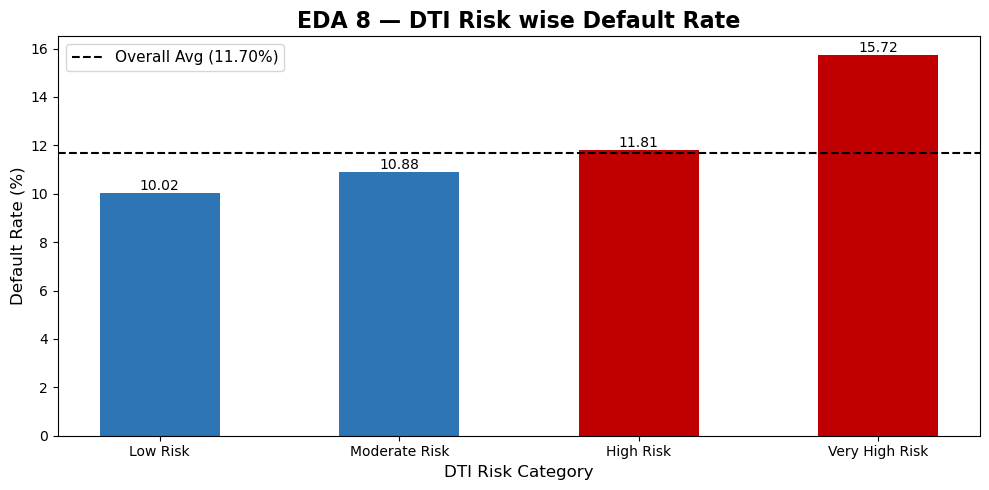

In [80]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#C00000' if r > 11.7 else '#2E75B6' for r in dti_default['Default_Rate']]
bars = ax.bar(dti_default.index, dti_default['Default_Rate'], color=colors, width=0.5)
ax.bar_label(bars)

ax.axhline(y=11.7, color='black', linestyle='--', linewidth=1.5, label='Overall Avg (11.70%)')
ax.set_title('EDA 8 — DTI Risk wise Default Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('DTI Risk Category', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda8_dti_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [81]:
print(dti_default)


                Default_Rate  Defaulters  Total_Loans
DTI_Risk                                             
Low Risk               10.02       13348       133230
Moderate Risk          10.88        9982        91722
High Risk              11.81        6421        54366
Very High Risk         15.72       11503        73182


## EDA 8 — DTI Risk wise Default Rate

**Key Finding:** People who spend too much of their income on EMI 
are more likely to default. Very High Risk DTI group defaults at 
15.72% vs only 10.02% for Low Risk group.

- Low Risk:       10.02% — safest — EMI is small compared to income
- Moderate Risk:  10.88% — still safe — managing well
- High Risk:      11.81% — above average — starting to struggle
- Very High Risk: 15.72% — highest risk — 11,503 people defaulted

**Business Insight:**
DTI Risk shows a clear pattern — as DTI goes up, defaults go up too.
People in Very High Risk DTI category are paying too much EMI 
compared to their income — that is why they default more.
Bank should not give loans to people whose DTI will go above 
a safe limit after taking the new loan. This is one of the 
strongest warning signs before giving a loan.

# EDA 9 — Region wise Default Rate

In [82]:
print(all_columns)

['Applicant_ID', 'Applicant_Name', 'Age', 'Gender', 'City', 'Region', 'Employment_Type', 'Education', 'Marital_Status', 'Annual_Income', 'Credit_Score', 'Dependents', 'Years_At_Job', 'Own_House', 'Credit_Score_Category', 'Age_Group', 'Income_Category', 'Loan_ID', 'Loan_Type', 'Loan_Amount', 'Interest_Rate', 'Loan_Tenure_Months', 'Loan_Purpose', 'Loan_Grade', 'Issue_Date', 'Debt_To_Income_%', 'Loan_Status', 'Issue_Year', 'Issue_Month', 'Issue_Quarter', 'DTI_Risk', 'Loan_Size', 'Repayment_ID', 'EMI_Month', 'Due_Date', 'Paid_Date', 'EMI_Amount', 'Amount_Paid', 'DPD_Days', 'Payment_Status', 'Default_Flag']


In [83]:
df['Region'].unique()

array(['North', 'East', 'West', 'South', 'Central'], dtype=object)

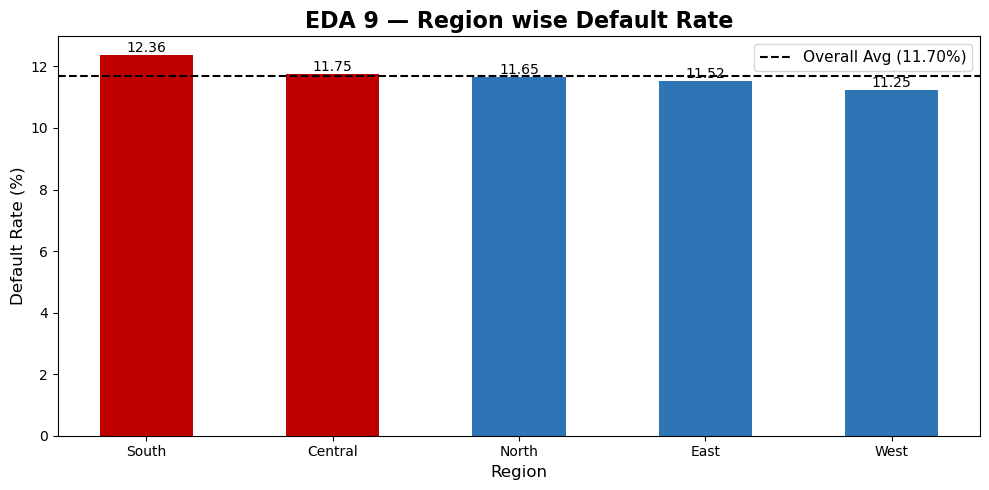

In [86]:
region_default = df.groupby('Region').agg(
    Default_Rate=('Default_Flag', lambda x: round(x.mean() * 100, 2)),
    Defaulters=('Default_Flag', 'sum'),
    Total_Loans=('Default_Flag', 'count')
).sort_values('Default_Rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#C00000' if r > 11.7 else '#2E75B6' for r in region_default['Default_Rate']]
bars = ax.bar(region_default.index, region_default['Default_Rate'], color=colors, width=0.5)
ax.bar_label(bars)

ax.axhline(y=11.7, color='black', linestyle='--', linewidth=1.5, label='Overall Avg (11.70%)')
ax.set_title('EDA 9 — Region wise Default Rate', fontsize=16, fontweight='bold')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda9_region_default.png', dpi=150, bbox_inches='tight')
plt.show()


In [87]:
print(region_default)


         Default_Rate  Defaulters  Total_Loans
Region                                        
South           12.36        8512        68856
Central         11.75        8326        70860
North           11.65        8206        70434
East            11.52        8316        72192
West            11.25        7894        70158


## EDA 9 — Region wise Default Rate

**Key Finding:** All regions have very similar default rates.
South is the highest at 12.36% and West is the lowest at 11.25% — 
the gap is only 1.11%.

- South:   12.36% — slightly above average
- Central: 11.75% — just above average
- North:   11.65% — just below average
- East:    11.52% — below average
- West:    11.25% — safest region

**Business Insight:**
Region is the weakest predictor we have seen so far — only 1.11% 
gap between highest and lowest. Defaults are happening almost equally 
across all regions. This means where a person lives does not really 
affect whether they will default or not. Other factors like Credit Score, 
Loan Grade and DTI are much more important than Region.

# EDA 10 — Correlation Heatmap

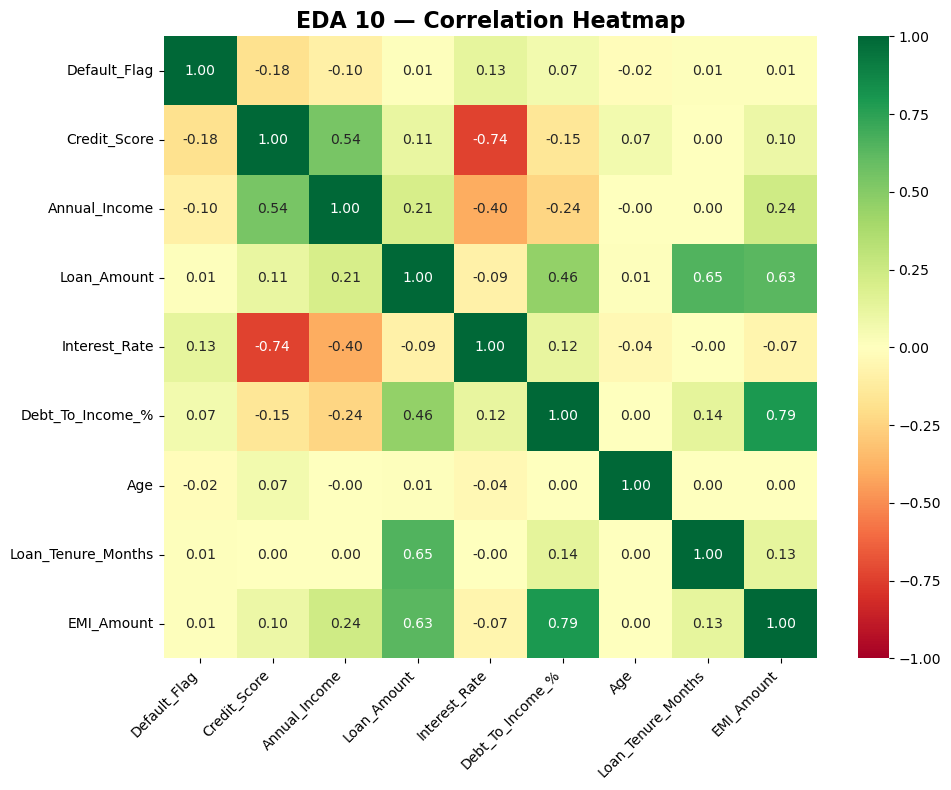

In [101]:
corr_cols = ['Default_Flag', 'Credit_Score', 'Annual_Income', 
             'Loan_Amount', 'Interest_Rate', 'Debt_To_Income_%', 
             'Age', 'Loan_Tenure_Months', 'EMI_Amount']

corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix, 
            annot=True,        # har cell mein value print karo
            fmt='.2f',         # 2 decimal places
            cmap='RdYlGn',     # same color scheme
            vmin=-1, vmax=1,   # scale -1 to +1
            ax=ax)

ax.set_title('EDA 10 — Correlation Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig('eda10_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA 10 — Correlation Heatmap

**Key Finding:** No single factor strongly predicts default on its own.
Credit Score has the strongest connection with default (-0.18) 
and Age has almost no connection (-0.02).

**Correlations with Default_Flag:**
- Credit_Score:       -0.18 — best predictor — higher score = fewer defaults
- Annual_Income:      -0.10 — more income = fewer defaults
- Interest_Rate:      +0.13 — higher rate = more defaults
- Debt_To_Income_%:   +0.07 — higher DTI = slightly more defaults
- Age, Loan_Amount, EMI_Amount — almost zero connection with default

**Other Strong Correlations found:**
- Credit_Score & Interest_Rate: -0.74 — bank charges more to risky borrowers
- DTI_% & EMI_Amount:           +0.79 — bigger EMI means higher DTI automatically
- Loan_Amount & Loan_Tenure:    +0.65 — bigger loan gets longer repayment time

**Business Insight:**
Default cannot be predicted by just one factor. 
Credit Score, Income and Interest Rate together give the best signals.
Bank should always look at the full picture — not just one number —
before deciding to give a loan.